In [2]:
import kagglehub
from pathlib import Path

# Baixar a última versão do dataset
data_path_str = kagglehub.dataset_download("muhammetzahitaydn/hardhat-vest-dataset-v3")
DATA_ROOT = Path(data_path_str)

print("Dataset baixado em:", DATA_ROOT)
print("Conteúdo da pasta:", list(DATA_ROOT.iterdir()))


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset baixado em: /Users/lucasmarzochi/.cache/kagglehub/datasets/muhammetzahitaydn/hardhat-vest-dataset-v3/versions/2
Conteúdo da pasta: [PosixPath('/Users/lucasmarzochi/.cache/kagglehub/datasets/muhammetzahitaydn/hardhat-vest-dataset-v3/versions/2/images'), PosixPath('/Users/lucasmarzochi/.cache/kagglehub/datasets/muhammetzahitaydn/hardhat-vest-dataset-v3/versions/2/labels')]


In [3]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from pathlib import Path

sns.set(style="whitegrid")

# Pastas de imagens e labels no formato YOLO
IMAGES_DIR = DATA_ROOT / "images"
LABELS_DIR = DATA_ROOT / "labels"

# Mapeamento id -> nome de classe (segundo o data.yaml do dataset)
CLASS_NAMES = {
    0: "Head",
    1: "Helmet",
    2: "Vest"
}

print("Imagens:", IMAGES_DIR)
print("Labels:", LABELS_DIR)


Imagens: /Users/lucasmarzochi/.cache/kagglehub/datasets/muhammetzahitaydn/hardhat-vest-dataset-v3/versions/2/images
Labels: /Users/lucasmarzochi/.cache/kagglehub/datasets/muhammetzahitaydn/hardhat-vest-dataset-v3/versions/2/labels


In [4]:
def parse_yolo_labels(split="train"):
    """
    Lê todos os arquivos .txt da pasta labels/<split> e devolve um DataFrame:
    colunas: [image, split, class_id, class_name, xc, yc, w, h]
    """
    labels_split_dir = LABELS_DIR / split
    images_split_dir = IMAGES_DIR / split

    rows = []

    for label_file in labels_split_dir.glob("*.txt"):
        image_name = label_file.stem + ".jpg"  # o dataset usa .jpg
        img_path = images_split_dir / image_name

        if not img_path.exists():
            # Se a imagem não existir, pula
            continue

        with open(label_file, "r") as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) != 5:
                    continue
                class_id = int(parts[0])
                xc, yc, w, h = map(float, parts[1:])
                rows.append({
                    "image": str(img_path),
                    "split": split,
                    "class_id": class_id,
                    "class_name": CLASS_NAMES.get(class_id, str(class_id)),
                    "xc": xc,
                    "yc": yc,
                    "w": w,
                    "h": h
                })

    return pd.DataFrame(rows)


df_train = parse_yolo_labels("train")
df_val   = parse_yolo_labels("val")
df_test  = parse_yolo_labels("test")

df = pd.concat([df_train, df_val, df_test], ignore_index=True)

df.head()


,image,split,class_id,class_name,xc,yc,w,h
0,/Users/lucasmarzochi/.cache/kagglehub/datasets...,train,0,Head,0.370,0.606667,0.108,0.074667
1,/Users/lucasmarzochi/.cache/kagglehub/datasets...,train,0,Head,0.885,0.650667,0.114,0.053333
2,/Users/lucasmarzochi/.cache/kagglehub/datasets...,train,0,Head,0.277,0.830000,0.090,0.084000
3,/Users/lucasmarzochi/.cache/kagglehub/datasets...,train,0,Head,0.669,0.633333,0.070,0.053333
4,/Users/lucasmarzochi/.cache/kagglehub/datasets...,train,0,Head,0.768,0.725333,0.148,0.072000


In [5]:
print("Informações gerais do DataFrame:")
df.info()

print("\nDistribuição de classes:")
print(df["class_name"].value_counts())

print("\nDistribuição por split:")
print(df["split"].value_counts())


Informações gerais do DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 172480 entries, 0 to 172479
Data columns (total 8 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   image       172480 non-null  object 
 1   split       172480 non-null  object 
 2   class_id    172480 non-null  int64  
 3   class_name  172480 non-null  object 
 4   xc          172480 non-null  float64
 5   yc          172480 non-null  float64
 6   w           172480 non-null  float64
 7   h           172480 non-null  float64
dtypes: float64(4), int64(1), object(3)
memory usage: 10.5+ MB

Distribuição de classes:
class_name
Vest      120433
Head       44154
Helmet      7893
Name: count, dtype: int64

Distribuição por split:
split
train    136290
val       18500
test      17690
Name: count, dtype: int64


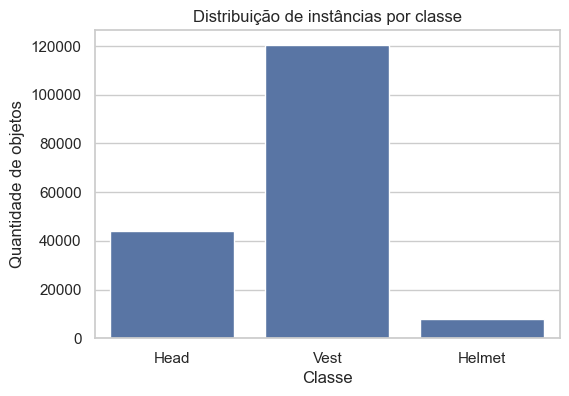

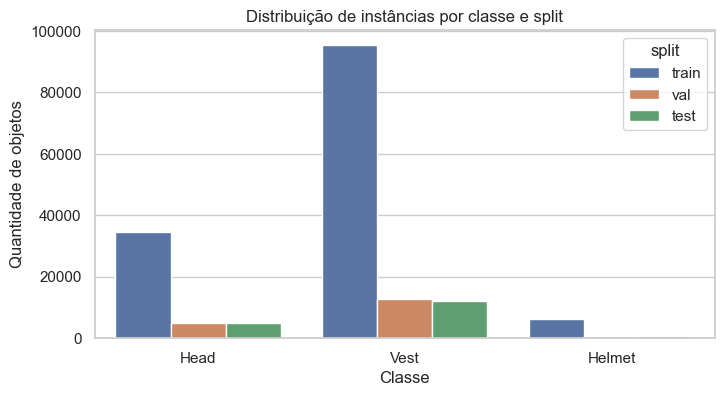

In [6]:
plt.figure(figsize=(6,4))
sns.countplot(x="class_name", data=df)
plt.title("Distribuição de instâncias por classe")
plt.xlabel("Classe")
plt.ylabel("Quantidade de objetos")
plt.show()


# Distribuição de classes por split
plt.figure(figsize=(8,4))
sns.countplot(x="class_name", hue="split", data=df)
plt.title("Distribuição de instâncias por classe e split")
plt.xlabel("Classe")
plt.ylabel("Quantidade de objetos")
plt.show()


Resumo estatístico da área relativa das boxes:
count    172480.000000
mean          0.013013
std           0.045718
min           0.000009
25%           0.000651
50%           0.001815
75%           0.007284
max           0.993304
Name: area_rel, dtype: float64


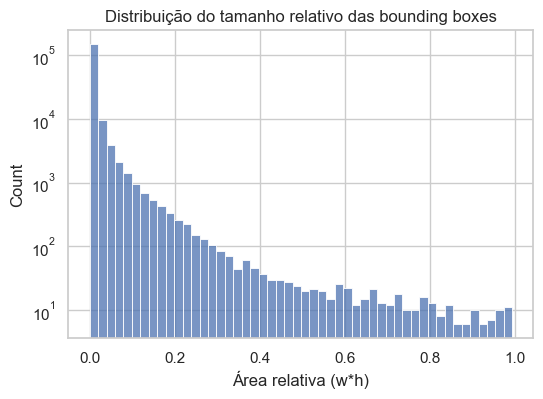


Resumo do nº de objetos por imagem:
count    18937.000000
mean         9.108095
std         16.277175
min          1.000000
25%          2.000000
50%          4.000000
75%          8.000000
max        421.000000
Name: num_objs, dtype: float64


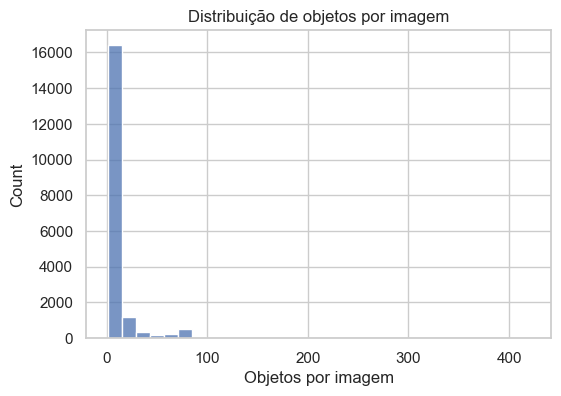

In [7]:
df["area_rel"] = df["w"] * df["h"]

print("Resumo estatístico da área relativa das boxes:")
print(df["area_rel"].describe())

plt.figure(figsize=(6,4))
sns.histplot(df["area_rel"], bins=50)
plt.yscale("log")  # muitas boxes pequenas
plt.xlabel("Área relativa (w*h)")
plt.title("Distribuição do tamanho relativo das bounding boxes")
plt.show()

# Objetos por imagem
objs_per_image = df.groupby(["image", "split"])["class_id"].count().reset_index(name="num_objs")
print("\nResumo do nº de objetos por imagem:")
print(objs_per_image["num_objs"].describe())

plt.figure(figsize=(6,4))
sns.histplot(objs_per_image["num_objs"], bins=30)
plt.xlabel("Objetos por imagem")
plt.title("Distribuição de objetos por imagem")
plt.show()


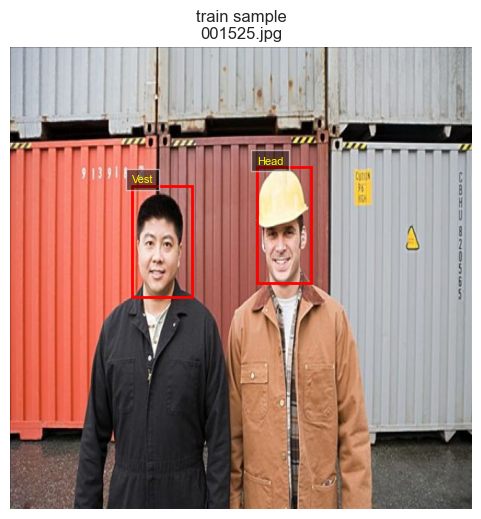

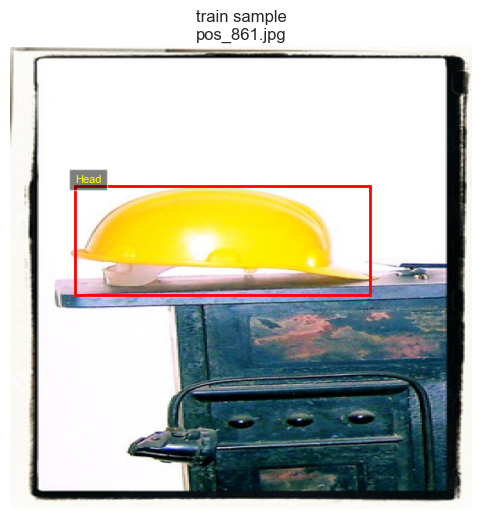

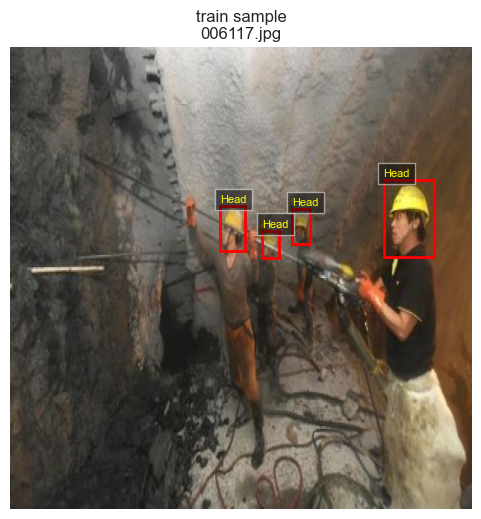

In [8]:
import matplotlib.patches as patches

def show_examples_with_boxes(split="train", n=3):
    subset = df[df["split"] == split]
    sample_images = subset["image"].drop_duplicates().sample(n)

    for img_path in sample_images:
        img_path = Path(img_path)
        img = Image.open(img_path).convert("RGB")
        fig, ax = plt.subplots(1, 1, figsize=(6,6))
        ax.imshow(img)

        w_img, h_img = img.size
        rows = subset[subset["image"] == str(img_path)]

        for _, row in rows.iterrows():
            xc, yc, w_rel, h_rel = row["xc"], row["yc"], row["w"], row["h"]
            bw = w_rel * w_img
            bh = h_rel * h_img
            bx = (xc * w_img) - bw / 2
            by = (yc * h_img) - bh / 2

            rect = patches.Rectangle(
                (bx, by),
                bw,
                bh,
                linewidth=2,
                edgecolor="red",
                facecolor="none"
            )
            ax.add_patch(rect)
            ax.text(
                bx,
                by - 5,
                row["class_name"],
                fontsize=8,
                color="yellow",
                bbox=dict(facecolor="black", alpha=0.5)
            )

        ax.set_title(f"{split} sample\n{img_path.name}")
        plt.axis("off")
        plt.show()

# Exemplo: 3 imagens de treino
show_examples_with_boxes("train", n=3)


In [9]:
# Imagens de treino existentes na pasta
all_train_images = set((IMAGES_DIR / "train").glob("*.jpg"))
labeled_train_images = set(Path(p) for p in df_train["image"].unique())

unlabeled_images = all_train_images - labeled_train_images
print(f"Nº de imagens de treino sem label: {len(unlabeled_images)}")

# Checar duplicatas no DataFrame
num_duplicated = df.duplicated().sum()
print(f"Nº de linhas duplicadas no df: {num_duplicated}")

# (Opcional) remover duplicatas
if num_duplicated > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print("Duplicatas removidas. Novo tamanho do df:", len(df))


Nº de imagens de treino sem label: 10
Nº de linhas duplicadas no df: 0
